In [19]:
# ===============================
# 1. Import Libraries
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [21]:
# For warnings
import warnings
warnings.filterwarnings("ignore")

In [22]:

# ===============================
# 2. Load Dataset (Yahoo Finance)
# ===============================
data = yf.download("AAPL", start="2018-01-01", end="2023-01-01")
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2018-01-02  40.380989  40.390368  39.677733  39.888712  102223600
2018-01-03  40.373970  40.917824  40.310679  40.444296  118071600
2018-01-04  40.561493  40.664638  40.338796  40.446626   89738400
2018-01-05  41.023304  41.110038  40.566188  40.657611   94640000
2018-01-08  40.870934  41.166300  40.772474  40.870934   82271200


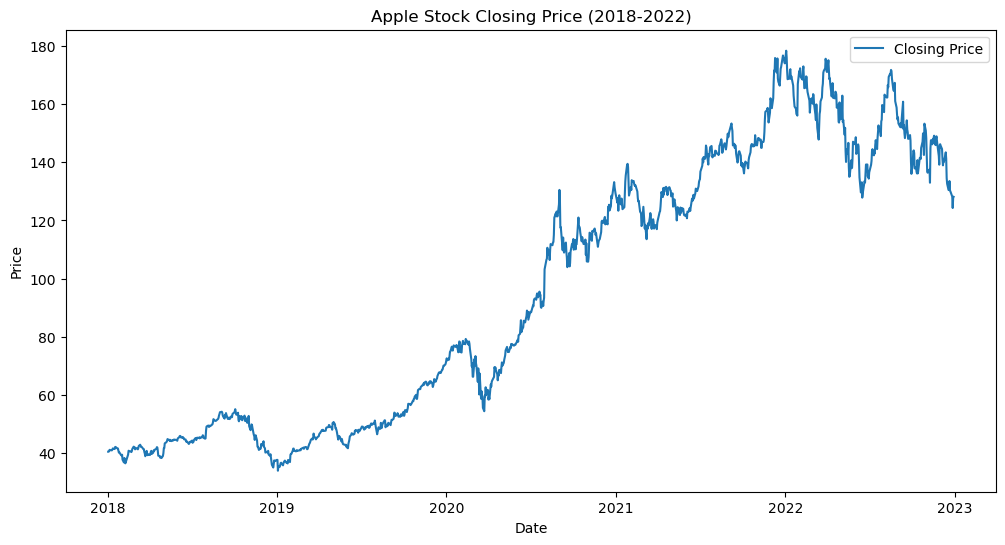

In [23]:
# ===============================
# 3. Exploratory Data Analysis
# ===============================
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label="Closing Price")
plt.title("Apple Stock Closing Price (2018-2022)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


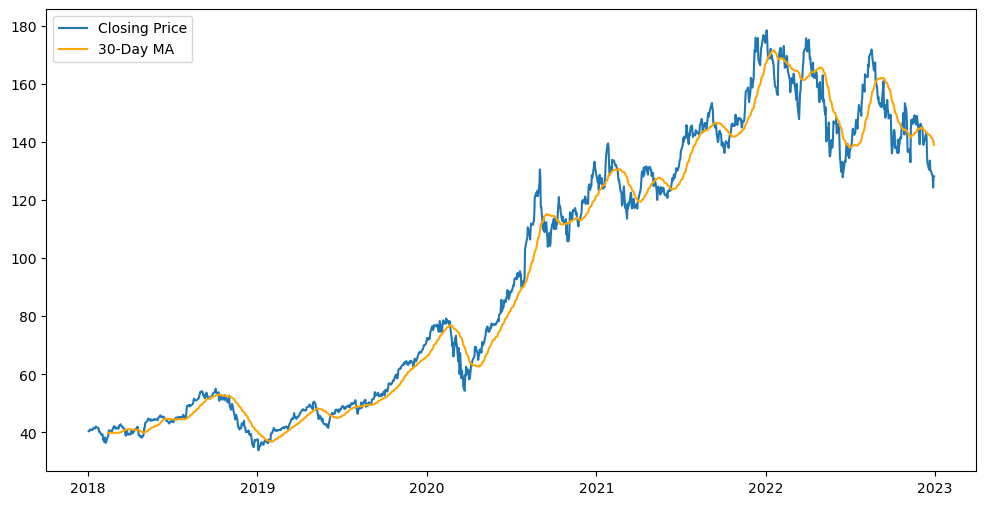

In [24]:
# Moving Averages
data['MA30'] = data['Close'].rolling(30).mean()
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label="Closing Price")
plt.plot(data['MA30'], label="30-Day MA", color="orange")
plt.legend()
plt.show()

In [25]:
# ===============================
# 4. Check Stationarity (ADF Test)
# ===============================
result = adfuller(data['Close'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])  # p < 0.05 → Stationary


ADF Statistic: -1.063803181463788
p-value: 0.729288893855287


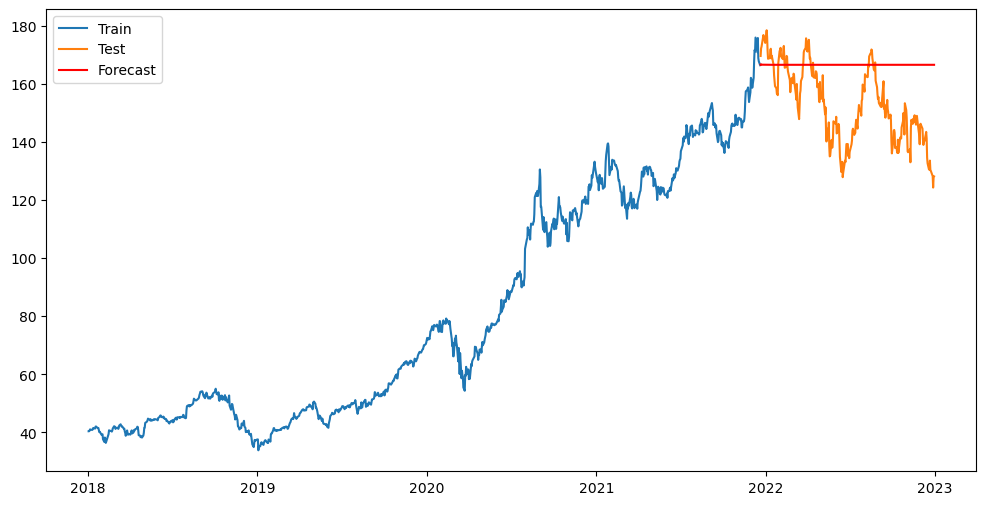

In [37]:

# ===============================
# 5. ARIMA Model
# ===============================
train = data['Close'][:1000]
test = data['Close'][1000:]

model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()
forecast = model_fit.forecast(steps=len(test))

plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, forecast, label="Forecast", color="red")
plt.legend()
plt.show()

09:14:17 - cmdstanpy - INFO - Chain [1] start processing
09:14:19 - cmdstanpy - INFO - Chain [1] done processing


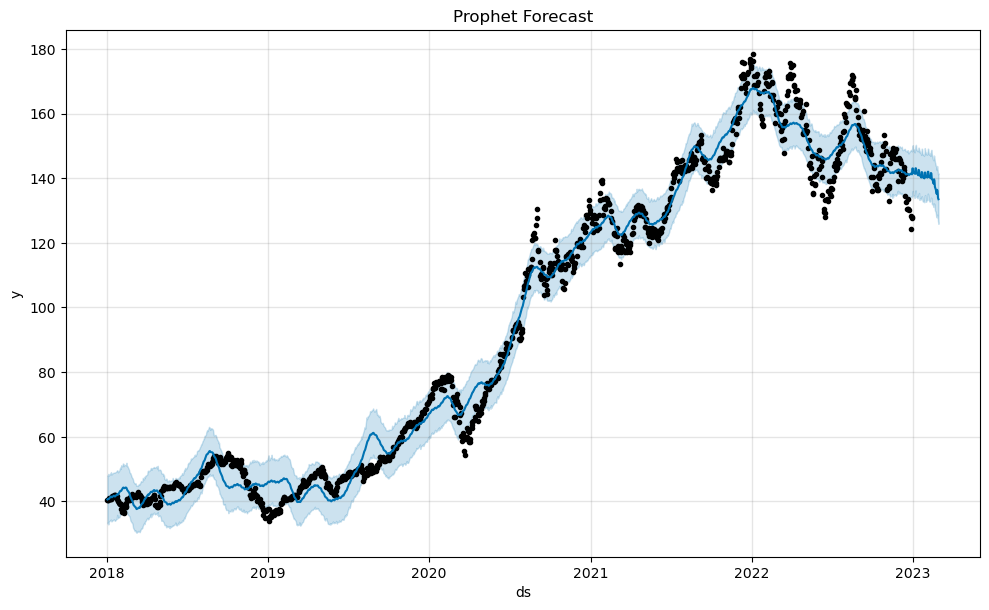

In [38]:
# ===============================
# 6. Prophet Model
# ===============================
df = data[['Close']].reset_index()
df.columns = ['ds', 'y']

prophet_model = Prophet()
prophet_model.fit(df)

future = prophet_model.make_future_dataframe(periods=60)  # 60 days forecast
forecast = prophet_model.predict(future)

prophet_model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()


In [39]:
# ===============================
# 7. LSTM Model (Deep Learning)
# ===============================
# Scale data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(np.array(data['Close']).reshape(-1,1))

# Train-test split
train_size = int(len(scaled_data)*0.8)
train_data, test_data = scaled_data[:train_size], scaled_data[train_size:]

In [40]:
# Create sequences
def create_dataset(dataset, time_step=100):
    X, y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [41]:
# Reshape [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [42]:
# LSTM Model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step,1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')


In [43]:
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.0447
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0018
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 8.9008e-04 
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 8.6005e-04 
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 8.0910e-04 
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 7.9937e-04
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 7.5972e-04
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 7.6239e-04
Epoch 9/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 7.5849e-04 
Epoch 10/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 7.0466e-04 


In [44]:
# Prediction
y_pred = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred.reshape(-1,1))
y_test = scaler.inverse_transform(y_test.reshape(-1,1))


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step


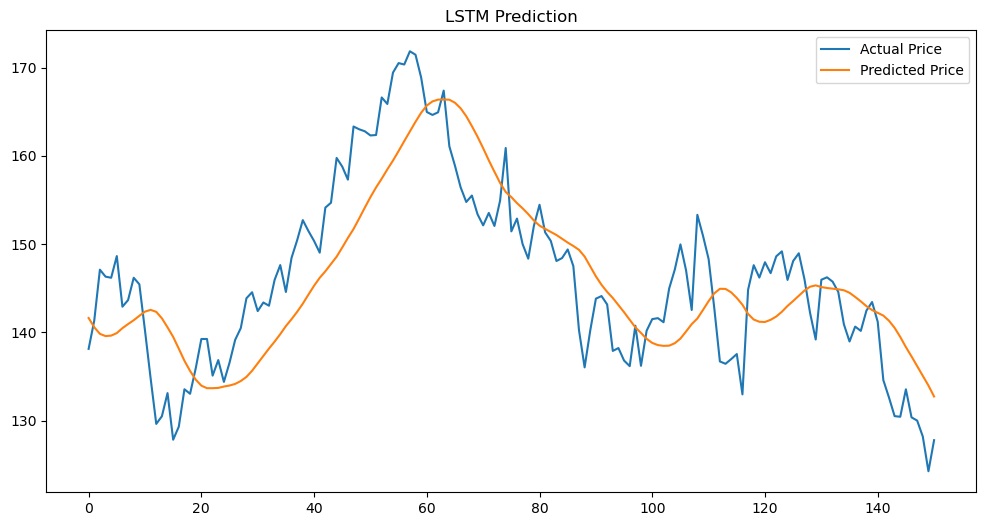

In [45]:
# Plot Results
plt.figure(figsize=(12,6))
plt.plot(y_test, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.title("LSTM Prediction")
plt.legend()
plt.show()